In [2]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
zip_path = "/content/drive/MyDrive/Projects/ML4Sci Test Projects/lens-finding-test.zip"
extract_path = "/content/lens_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted. Folder structure:")
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        subindent = ' ' * 2 * (level + 1)
        print(f'{subindent}{len(files)} files')

Extracted. Folder structure:
lens_dataset/
  0 files
  __MACOSX/
    4 files
    train_lenses/
      1730 files
    test_lenses/
      195 files
    train_nonlenses/
      28675 files
    test_nonlenses/
      19455 files
  train_lenses/
    1730 files
  test_lenses/
    195 files
  train_nonlenses/
    28675 files
  test_nonlenses/
    19455 files


In [6]:
data_dir = "/content/lens_dataset"

class LensFinderDataset(Dataset):
    def __init__(self, lens_dir, nonlens_dir, transform=None):
        self.transform = transform
        self.samples = []

        for f in os.listdir(lens_dir):
            if f.endswith('.npy'):
                self.samples.append((os.path.join(lens_dir, f), 1))

        for f in os.listdir(nonlens_dir):
            if f.endswith('.npy'):
                self.samples.append((os.path.join(nonlens_dir, f), 0))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = np.load(img_path)           # shape: (3, 64, 64)
        img = torch.tensor(img, dtype=torch.float32)
        if self.transform:
            img = self.transform(img)
        return img, label

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = LensFinderDataset(
    os.path.join(data_dir, "train_lenses"),
    os.path.join(data_dir, "train_nonlenses"),
    transform=train_transform
)

test_dataset = LensFinderDataset(
    os.path.join(data_dir, "test_lenses"),
    os.path.join(data_dir, "test_nonlenses"),
    transform=test_transform
)

# class imbalance with weighted sampler
labels = [s[1] for s in train_dataset.samples]
class_counts = [labels.count(0), labels.count(1)]
weights = [1.0 / class_counts[l] for l in labels]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train samples: {len(train_dataset)} (lenses: {class_counts[1]}, non-lenses: {class_counts[0]})")
print(f"Test samples: {len(test_dataset)}")

Train samples: 30405 (lenses: 1730, non-lenses: 28675)
Test samples: 19650


In [8]:
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 1)  # binary classification
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model.fc)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 181MB/s]


Linear(in_features=512, out_features=1, bias=True)


In [9]:
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

epochs = 10
for epoch in range(epochs):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, test_loader, criterion)
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Test Loss: {val_loss:.4f} Acc: {val_acc:.4f}")


Epoch 1/10 | Train Loss: 0.2172 Acc: 0.9165 | Test Loss: 0.1158 Acc: 0.9527
Epoch 2/10 | Train Loss: 0.1582 Acc: 0.9430 | Test Loss: 0.2099 Acc: 0.9189
Epoch 3/10 | Train Loss: 0.1438 Acc: 0.9463 | Test Loss: 0.1180 Acc: 0.9566
Epoch 4/10 | Train Loss: 0.1215 Acc: 0.9562 | Test Loss: 0.0842 Acc: 0.9666
Epoch 5/10 | Train Loss: 0.1047 Acc: 0.9618 | Test Loss: 0.0894 Acc: 0.9664
Epoch 6/10 | Train Loss: 0.0970 Acc: 0.9645 | Test Loss: 0.1553 Acc: 0.9446
Epoch 7/10 | Train Loss: 0.0911 Acc: 0.9679 | Test Loss: 0.1295 Acc: 0.9500
Epoch 8/10 | Train Loss: 0.0850 Acc: 0.9687 | Test Loss: 0.0983 Acc: 0.9663
Epoch 9/10 | Train Loss: 0.0758 Acc: 0.9734 | Test Loss: 0.0904 Acc: 0.9678
Epoch 10/10 | Train Loss: 0.0748 Acc: 0.9727 | Test Loss: 0.0848 Acc: 0.9701


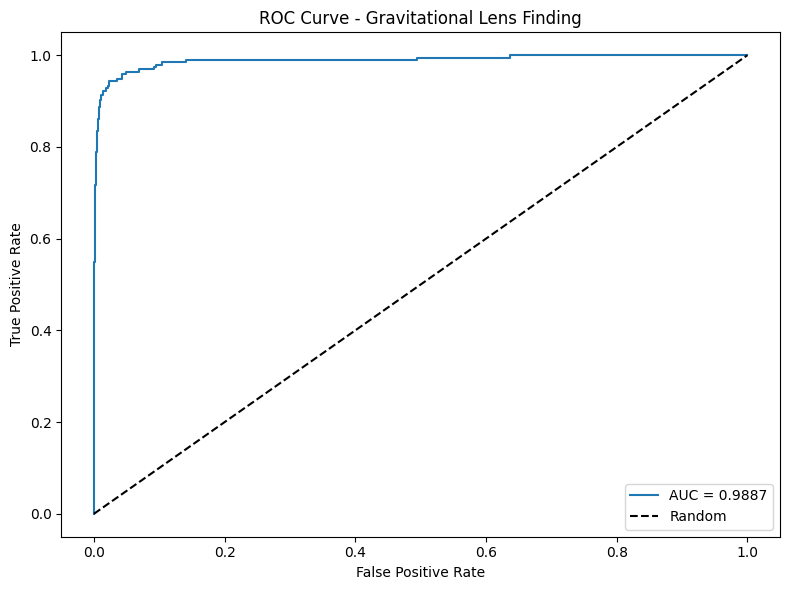

AUC Score: 0.9887


In [10]:
model.eval()
all_labels = []
all_probs = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.sigmoid(outputs).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs).flatten()
all_labels = np.array(all_labels)

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Gravitational Lens Finding')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve_test5.png', dpi=150)
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

In [13]:
save_path = "/content/ML4Sci-DeepLense-GSoC2026/Test_V_Lens_Finding/resnet18_test1.pth"
torch.save(model.state_dict(), save_path)
print("Model saved.")

Model saved.


In [15]:
save_path = "/content/ML4Sci-DeepLense-GSoC2026/Test_V_Lens_Finding/roc_curve_test1.png"
plt.savefig(save_path, dpi=150)
print("ROC curve saved.")


ROC curve saved.


<Figure size 640x480 with 0 Axes>